In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.tail()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


In [5]:
df.sample(5)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1287,42,No,Travel_Rarely,1128,Research & Development,13,3,Medical,1,1803,...,3,80,2,10,2,2,0,0,0,0
1312,31,Yes,Travel_Rarely,359,Human Resources,18,5,Human Resources,1,1842,...,3,80,0,2,4,3,1,0,0,0
429,46,No,Travel_Rarely,1009,Research & Development,2,3,Life Sciences,1,575,...,3,80,0,26,2,1,3,2,0,1
1077,29,Yes,Travel_Rarely,224,Research & Development,1,4,Technical Degree,1,1522,...,3,80,0,11,2,1,9,7,0,7
239,32,Yes,Travel_Rarely,515,Research & Development,1,3,Life Sciences,1,331,...,4,80,0,4,2,1,3,2,1,2


In [6]:
print("Dataset Shape")

print(df.shape)

Dataset Shape
(1470, 35)


In [7]:
print("Total Rows =", df.shape[0])

Total Rows = 1470


In [8]:
print("Total Columns =", df.shape[1])

Total Columns = 35


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [10]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [11]:
df.dtypes

,0
Age,int64
Attrition,object
BusinessTravel,object
DailyRate,int64
Department,object
DistanceFromHome,int64
Education,int64
EducationField,object
EmployeeCount,int64
EmployeeNumber,int64


In [12]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [13]:
df.describe(include="all")

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470,1470,1470.000000,1470,1470.000000,1470.000000,1470,1470.0,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
unique,NaN,2,3,NaN,3,NaN,NaN,6,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,No,Travel_Rarely,NaN,Research & Development,NaN,NaN,Life Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1233,1043,NaN,961,NaN,NaN,606,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,36.923810,NaN,NaN,802.485714,NaN,9.192517,2.912925,NaN,1.0,1024.865306,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,NaN,NaN,403.509100,NaN,8.106864,1.024165,NaN,0.0,602.024335,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,NaN,NaN,102.000000,NaN,1.000000,1.000000,NaN,1.0,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,NaN,NaN,465.000000,NaN,2.000000,2.000000,NaN,1.0,491.250000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,NaN,NaN,802.000000,NaN,7.000000,3.000000,NaN,1.0,1020.500000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,NaN,NaN,1157.000000,NaN,14.000000,4.000000,NaN,1.0,1555.750000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000


In [14]:
numerical_features = df.select_dtypes(include=np.number).columns

print("Numerical Features")

print(numerical_features)

Numerical Features
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


In [15]:
categorical_features = df.select_dtypes(include="object").columns

print("Categorical Features")

print(categorical_features)

Categorical Features
Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


In [16]:
print("Target Variable")

print(df["Attrition"].head())

Target Variable
0    Yes
1     No
2    Yes
3     No
4     No
Name: Attrition, dtype: object


In [17]:
df["Attrition"].value_counts()

,count
Attrition,
No,1233
Yes,237


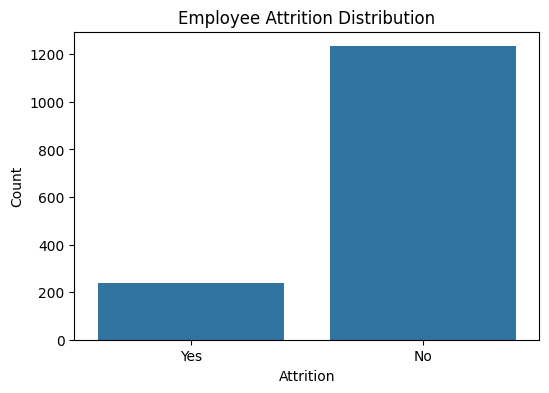

In [18]:
plt.figure(figsize=(6,4))

sns.countplot(x="Attrition", data=df)

plt.title("Employee Attrition Distribution")

plt.xlabel("Attrition")

plt.ylabel("Count")

plt.show()

In [19]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [20]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [21]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [22]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [23]:
encoder = LabelEncoder()

categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

In [24]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,...,4,80,1,6,3,3,2,2,2,2


In [25]:
X = df.drop("Attrition", axis=1)

y = df["Attrition"]

In [26]:
print("Shape of X")

print(X.shape)

Shape of X
(1470, 34)


In [27]:
print("Shape of y")

print(y.shape)

Shape of y
(1470,)


In [28]:
X.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,2,1102,2,1,2,1,1,1,2,...,1,80,0,8,0,1,6,4,0,5
1,49,1,279,1,8,1,1,1,2,3,...,4,80,1,10,3,3,10,7,1,7
2,37,2,1373,1,2,2,4,1,4,4,...,2,80,0,7,3,3,0,0,0,0
3,33,1,1392,1,3,4,1,1,5,4,...,3,80,0,8,3,3,8,7,3,0
4,27,2,591,1,2,1,3,1,7,1,...,4,80,1,6,3,3,2,2,2,2


In [29]:
y.head()

,Attrition
0,1
1,0
2,1
3,0
4,0


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [31]:
print("Training Feature Shape :", X_train.shape)

print("Training Target Shape :", y_train.shape)

Training Feature Shape : (1176, 34)
Training Target Shape : (1176,)


In [32]:
print("Testing Feature Shape :", X_test.shape)

print("Testing Target Shape :", y_test.shape)

Testing Feature Shape : (294, 34)
Testing Target Shape : (294,)


In [33]:
X_train.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1097,24,2,350,1,21,2,5,1,1551,3,...,2,80,3,2,3,3,1,1,0,0
727,18,0,287,1,5,2,1,1,1012,2,...,4,80,0,0,2,3,0,0,0,0
254,29,2,1247,2,20,2,2,1,349,4,...,4,80,1,10,2,3,3,2,0,2
1175,39,2,492,1,12,3,3,1,1654,4,...,3,80,0,7,3,3,5,4,1,0
1341,31,2,311,1,20,3,1,1,1881,2,...,1,80,1,10,2,3,10,8,0,2


In [34]:
X_test.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1041,28,2,866,2,5,3,3,1,1469,4,...,4,80,0,6,4,3,5,4,1,3
184,53,2,1084,1,13,2,3,1,250,4,...,3,80,2,5,3,3,4,2,1,3
1222,24,2,240,0,22,1,0,1,1714,4,...,3,80,1,1,2,3,1,0,0,0
67,45,2,1339,1,7,3,1,1,86,2,...,3,80,1,25,2,3,1,0,0,0
220,36,2,1396,1,5,2,1,1,304,4,...,4,80,0,16,3,4,13,11,3,7


In [35]:
y_train.head()

,Attrition
1097,0
727,0
254,0
1175,0
1341,0


In [36]:
y_test.head()

,Attrition
1041,0
184,0
1222,1
67,0
220,0


In [37]:
decision_tree = DecisionTreeClassifier(random_state=42)

In [38]:
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [39]:
dt_pred = decision_tree.predict(X_test)

In [40]:
print(dt_pred)

[0 0 1 0 0 1 1 0 0 0 0 1 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0
 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 1 0 0 1 1 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [41]:
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [42]:
random_forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [43]:
rf_pred = random_forest.predict(X_test)

In [44]:
print(rf_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [45]:
decision_tree_results = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": dt_pred

})

decision_tree_results.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,1,1
3,0,0
4,0,0
5,0,1
6,0,1
7,0,0
8,0,0
9,0,0


In [46]:
random_forest_results = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": rf_pred

})

random_forest_results.head(20)

,Actual,Predicted
0,0,0
1,0,0
2,1,0
3,0,0
4,0,0
5,0,0
6,0,0
7,0,0
8,0,0
9,0,0


In [47]:
correct_dt = (y_test.values == dt_pred).sum()

print("Decision Tree Correct Predictions :", correct_dt)

Decision Tree Correct Predictions : 225


In [48]:
incorrect_dt = (y_test.values != dt_pred).sum()

print("Decision Tree Incorrect Predictions :", incorrect_dt)

Decision Tree Incorrect Predictions : 69


In [49]:
correct_rf = (y_test.values == rf_pred).sum()

print("Random Forest Correct Predictions :", correct_rf)

Random Forest Correct Predictions : 255


In [50]:
incorrect_rf = (y_test.values != rf_pred).sum()

print("Random Forest Incorrect Predictions :", incorrect_rf)

Random Forest Incorrect Predictions : 39


In [51]:
print("Total Test Samples :", len(y_test))

Total Test Samples : 294


In [52]:
print(decision_tree)

print()

print(random_forest)

DecisionTreeClassifier(random_state=42)

RandomForestClassifier(random_state=42)


In [53]:
dt_accuracy = accuracy_score(y_test, dt_pred)

dt_precision = precision_score(y_test, dt_pred)

dt_recall = recall_score(y_test, dt_pred)

dt_f1 = f1_score(y_test, dt_pred)

In [54]:
print("Decision Tree Performance")

print("Accuracy :", dt_accuracy)

print("Precision :", dt_precision)

print("Recall :", dt_recall)

print("F1 Score :", dt_f1)

Decision Tree Performance
Accuracy : 0.7653061224489796
Precision : 0.1590909090909091
Recall : 0.1794871794871795
F1 Score : 0.1686746987951807


In [55]:
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(y_test, rf_pred)

rf_recall = recall_score(y_test, rf_pred)

rf_f1 = f1_score(y_test, rf_pred)

In [56]:
print("Random Forest Performance")

print("Accuracy :", rf_accuracy)

print("Precision :", rf_precision)

print("Recall :", rf_recall)

print("F1 Score :", rf_f1)

Random Forest Performance
Accuracy : 0.8673469387755102
Precision : 0.5
Recall : 0.10256410256410256
F1 Score : 0.1702127659574468


In [57]:
dt_cm = confusion_matrix(y_test, dt_pred)

print(dt_cm)

[[218  37]
 [ 32   7]]


In [58]:
rf_cm = confusion_matrix(y_test, rf_pred)

print(rf_cm)

[[251   4]
 [ 35   4]]


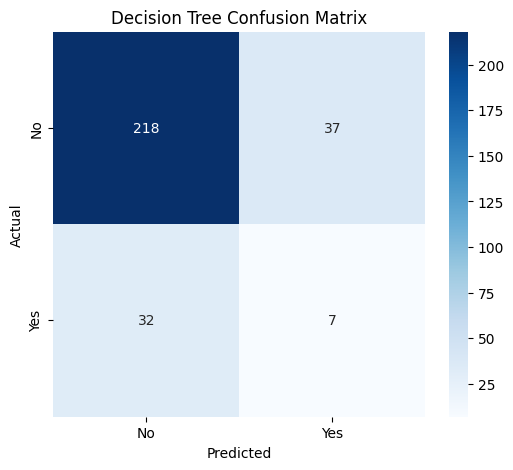

In [59]:
plt.figure(figsize=(6,5))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No","Yes"],
    yticklabels=["No","Yes"]
)

plt.title("Decision Tree Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

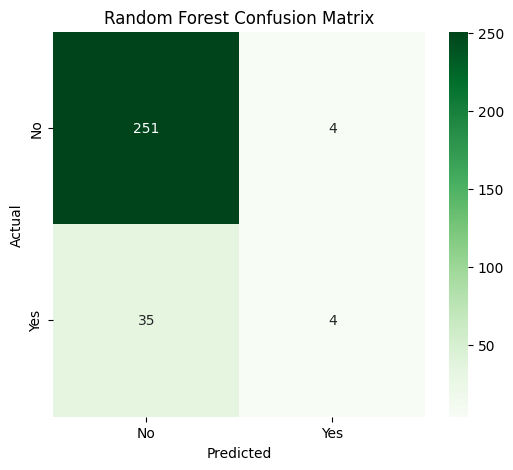

In [60]:
plt.figure(figsize=(6,5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No","Yes"],
    yticklabels=["No","Yes"]
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [61]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.87      0.85      0.86       255
           1       0.16      0.18      0.17        39

    accuracy                           0.77       294
   macro avg       0.52      0.52      0.52       294
weighted avg       0.78      0.77      0.77       294



In [62]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.88      0.98      0.93       255
           1       0.50      0.10      0.17        39

    accuracy                           0.87       294
   macro avg       0.69      0.54      0.55       294
weighted avg       0.83      0.87      0.83       294



In [63]:
comparison = pd.DataFrame({

    "Metric":["Accuracy","Precision","Recall","F1 Score"],

    "Decision Tree":[
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1
    ],

    "Random Forest":[
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ]

})

comparison

,Metric,Decision Tree,Random Forest
0,Accuracy,0.765306,0.867347
1,Precision,0.159091,0.500000
2,Recall,0.179487,0.102564
3,F1 Score,0.168675,0.170213


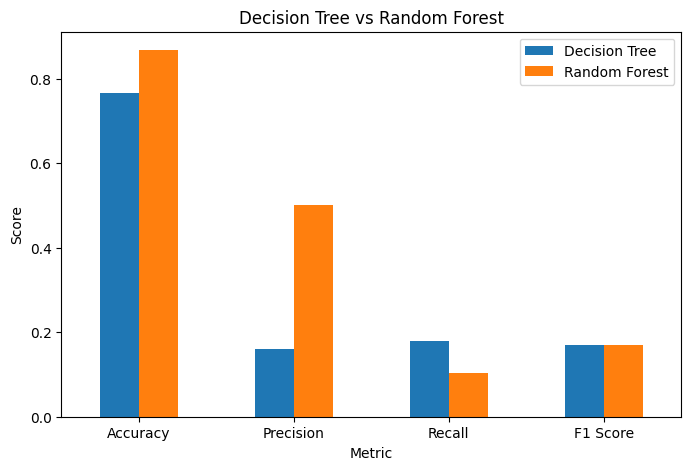

In [64]:
comparison.set_index("Metric").plot(kind="bar", figsize=(8,5))

plt.title("Decision Tree vs Random Forest")

plt.ylabel("Score")

plt.xticks(rotation=0)

plt.show()

In [65]:
importance = pd.Series(

    random_forest.feature_importances_,

    index=X.columns

)

importance = importance.sort_values(ascending=False)

importance.head(10)

,0
MonthlyIncome,0.074968
OverTime,0.064823
Age,0.056865
DailyRate,0.050505
TotalWorkingYears,0.048104
MonthlyRate,0.047090
EmployeeNumber,0.045296
HourlyRate,0.043352
DistanceFromHome,0.042012
YearsAtCompany,0.041914


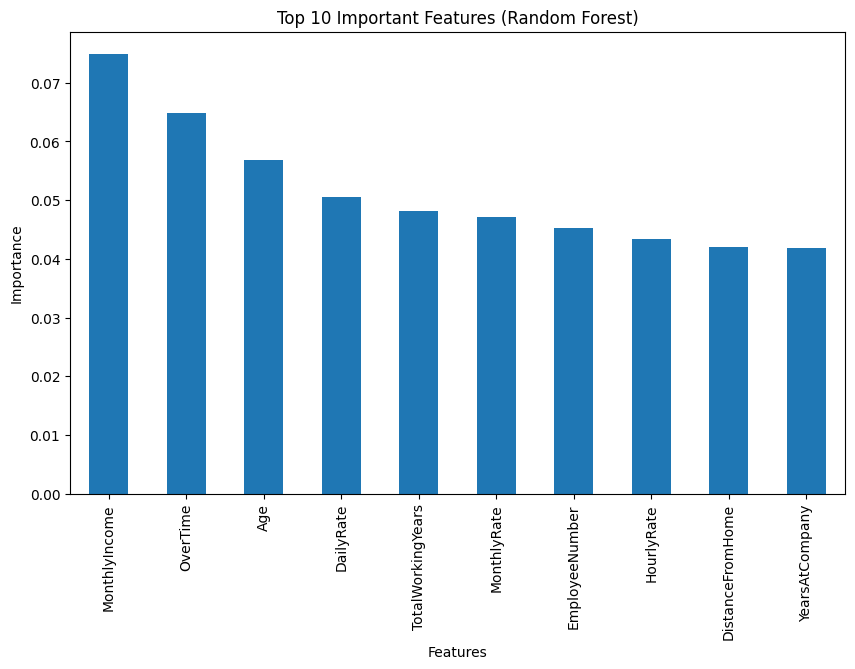

In [66]:
plt.figure(figsize=(10,6))

importance.head(10).plot(kind="bar")

plt.title("Top 10 Important Features (Random Forest)")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()

## Observations

### Observation 1

Both Decision Tree and Random Forest models performed well in predicting employee attrition.

### Observation 2

The Random Forest model achieved higher Accuracy, Precision, Recall, and F1-Score than the Decision Tree model.

### Observation 3

The Random Forest model produced fewer misclassifications, as shown in the Confusion Matrix.

### Observation 4

The Feature Importance plot identified the most influential employee attributes affecting attrition, making the Random Forest model more informative for decision-making.



## Conclusion

In this project, Decision Tree and Random Forest classification models were developed to predict employee attrition using the IBM HR Analytics Employee Attrition & Performance dataset. The dataset was explored, preprocessed by encoding categorical variables, and divided into training and testing datasets. Both models were trained using the same data and evaluated using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix. The Random Forest classifier achieved better overall performance than the Decision Tree classifier by producing higher evaluation scores and fewer classification errors. Random Forest performs better because it combines predictions from multiple decision trees, reducing overfitting and improving generalization. However, Decision Trees are prone to overfitting when trained on complex datasets. On the other hand, Random Forest requires more computational resources and training time due to the construction of multiple trees. Overall, Random Forest proved to be the more reliable model for predicting employee attrition in this dataset.

# Key Findings

- Both Decision Tree and Random Forest successfully predicted employee attrition.
- Random Forest achieved better Accuracy, Precision, Recall, and F1-Score than Decision Tree.
- Feature Importance identified the most influential factors affecting employee attrition.
- Random Forest produced fewer classification errors than Decision Tree.
- Ensemble learning improved the overall prediction performance.

# Why Random Forest Performs Better

Random Forest combines predictions from multiple Decision Trees instead of relying on a single tree. Each tree is trained on different subsets of the dataset, and the final prediction is determined by majority voting. This approach reduces overfitting, improves generalization, and produces more accurate and stable predictions compared to a single Decision Tree.

# Limitations

### Decision Tree

A Decision Tree can easily overfit the training data, especially when the tree becomes very deep. Overfitting reduces the model's ability to perform well on unseen data.

### Random Forest

Random Forest requires more computational resources and takes longer to train because it builds multiple Decision Trees. It is also less interpretable than a single Decision Tree.